In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, utils
import numpy as np
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [ ]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Linear(64*7*7, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.25),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)  
        x = self.classifier(x)
        return x

    

In [20]:
model = SimpleCNN()
model.load_state_dict(torch.load('../models/saved_models/cnn_model_best.pth'))
model.eval()

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=3136, out_features=128, bias=True)
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [21]:
mean = 0.1307
std = 0.3081

transformer = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Normalize((mean,), (std,))
])

testData = datasets.MNIST('./data', train=False, download=True, transform=transformer)
testLoader = DataLoader(testData, batch_size=200, shuffle=False)

images, labels = next(iter(testLoader))

print(images.shape)
print(labels.shape)

torch.Size([200, 1, 28, 28])
torch.Size([200])


In [ ]:
y_true = []
y_pred = []

with torch.no_grad():
    corr = 0
    total = 0
    for images, labels in testLoader:
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        total += labels.size(0)
        corr += (preds == labels).sum().item()

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

    accuracy = 100 * corr / total
    print(f"Test Accuracy: {accuracy:.2f}%")



Test Accuracy: 99.11%


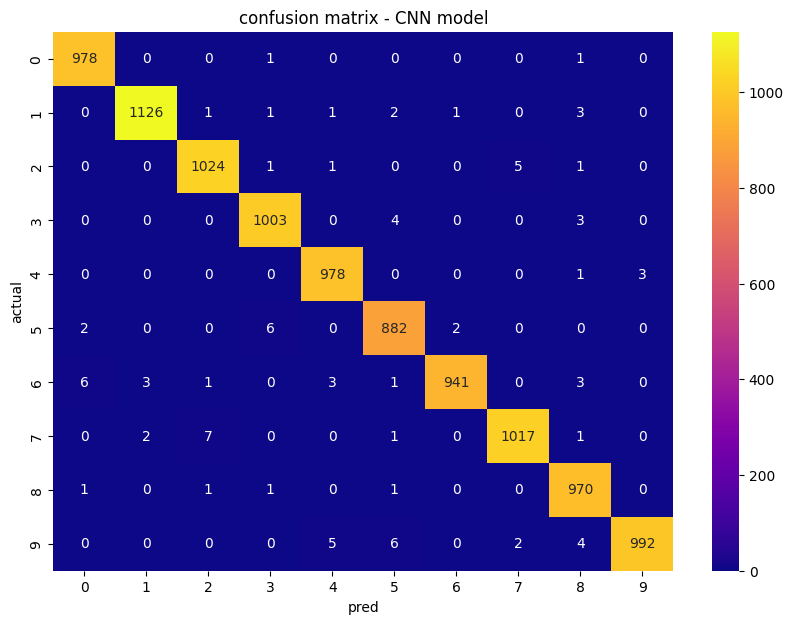

In [29]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='plasma')
plt.xlabel('pred')
plt.ylabel('actual')
plt.title('confusion matrix - CNN model')
plt.show()


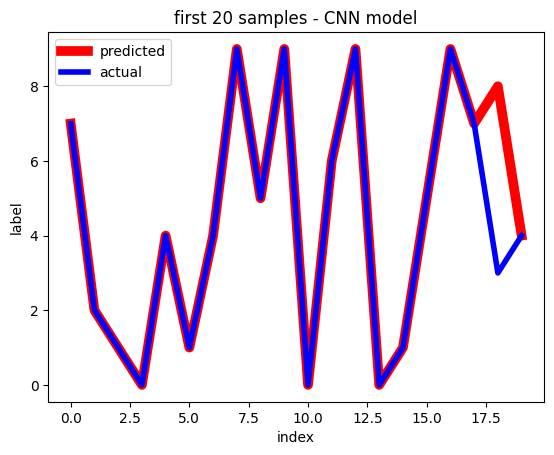

In [30]:
plt.plot(y_pred[:20], 'red', label='predicted', linewidth=7)
plt.plot(y_true[:20], 'blue', label='actual', linewidth=4)
plt.title('first 20 samples - CNN model')
plt.xlabel('index')
plt.ylabel('label')
plt.legend()
plt.show()

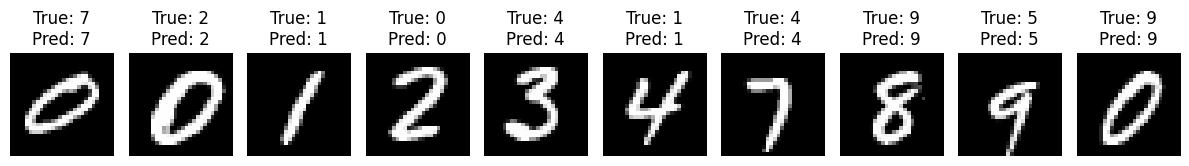

In [31]:
def sample_pred(images, true_labels, pred_labels, n=10):
    plt.figure(figsize=(12, 6))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(images[i].squeeze(), cmap='gray') 
        plt.title(f"True: {true_labels[i]}\nPred: {pred_labels[i]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

sample_pred(images, y_true, y_pred)